# MVP -- Problematica 2 v2: 6 Cooperativas Seleccionadas

**Empresa**: Apoyo Crediticio  
**Alcance**: Modelo enfocado en las 6 cooperativas activas de mayor volumen.  
**Cooperativas objetivo**: BUSINESS - COOPIDESARROLLO - COOPSANDER - COPFINANCIAR - EXCELCREDIT - PRONALCREDIT  
**Pipeline**: Dos etapas - filtro de reglas de negocio + ranking ML.  
**Imagenes**: guardadas en `imagenes/`

In [1]:
import os, re, unicodedata, pickle, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.2f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, top_k_accuracy_score
)

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
    print('XGBoost disponible')
except ImportError:
    XGBOOST_AVAILABLE = False
    print('XGBoost no instalado -> pip install xgboost')

IMG_DIR = 'imagenes'
os.makedirs(IMG_DIR, exist_ok=True)

print('Librerias cargadas correctamente')
print(f'Ejecucion: {datetime.now().strftime("%Y-%m-%d %H:%M")}')
print(f'Imagenes en: {IMG_DIR}/')

XGBoost disponible
Librerias cargadas correctamente
Ejecucion: 2026-04-19 20:43
Imagenes en: imagenes/


---
## 1. Carga y Limpieza de Datos

In [2]:
RUTA = '../data/dataset_limpio.csv'
df_raw = pd.read_csv(RUTA)
print(f'Dataset cargado: {df_raw.shape[0]} filas x {df_raw.shape[1]} columnas')
df_raw.head(3)

Dataset cargado: 1656 filas x 15 columnas


,ID_CLIENTE,FECHA,TIPO DE CREDITO,COOPERATIVA,MONTO,PLAZO,PAGADURIA,ANIO_NACIMIENTO,ESTADO,FECHA DE DESEMBOLSO,EDAD_AL_PRESTAMO,DIAS_HASTA_DESEMBOLSO,MONTO_M,ANIO,MES
0,1,2019-01-08,REFINANCIACIÓN,BUSINESS,"2,700,000.00",48.00,COLPENSIONES,"1,961.00",DESEMBOLSADO,2022-02-21,58.00,NaN,2.70,"2,019.00",1.00
1,2,2019-05-29,LIBRE INVERSIÓN,COOPIDESARROLLO,"6,000,000.00",36.00,COLPENSIONES,"1,939.00",DESEMBOLSADO,2019-06-11,80.00,13.00,6.00,"2,019.00",5.00
2,3,2019-05-30,LIBRE INVERSIÓN,COOPIDESARROLLO,"5,000,000.00",48.00,CAGEN,"1,944.00",DESEMBOLSADO,2019-06-25,75.00,26.00,5.00,"2,019.00",5.00


In [3]:
def normalizar_texto(texto):
    if pd.isna(texto):
        return np.nan
    s = str(texto).upper().strip()
    s = unicodedata.normalize('NFD', s)
    s = ''.join(c for c in s if unicodedata.category(c) != 'Mn')
    return re.sub(r'\s+', ' ', s).strip()


def limpiar_dataset(df_input):
    df = df_input.copy()
    df['FECHA'] = pd.to_datetime(df['FECHA'], errors='coerce')
    df['FECHA DE DESEMBOLSO'] = pd.to_datetime(df['FECHA DE DESEMBOLSO'], errors='coerce')

    df['MONTO'] = pd.to_numeric(
        df['MONTO'].astype(str).str.replace(r'[$,\s]', '', regex=True), errors='coerce')
    df.loc[df['MONTO'] <= 0, 'MONTO'] = np.nan

    df['PLAZO'] = pd.to_numeric(df['PLAZO'], errors='coerce')
    df.loc[df['PLAZO'] <= 0, 'PLAZO'] = np.nan

    df['ESTADO'] = df['ESTADO'].apply(normalizar_texto)
    def _map_estado(v):
        if pd.isna(v): return np.nan
        if 'NO' in v or 'RECHAZ' in v: return 'NO DESEMBOLSADO'
        if 'DESEMBOLSADO' in v: return 'DESEMBOLSADO'
        return 'OTRO'
    df['ESTADO'] = df['ESTADO'].apply(_map_estado)

    df['ANIO_NACIMIENTO'] = pd.to_numeric(df['ANIO_NACIMIENTO'], errors='coerce')
    df.loc[(df['ANIO_NACIMIENTO'] >= 2020) | (df['ANIO_NACIMIENTO'] < 1920), 'ANIO_NACIMIENTO'] = np.nan

    df['EDAD_AL_PRESTAMO'] = pd.to_numeric(df['EDAD_AL_PRESTAMO'], errors='coerce')
    anio_credito = df['FECHA'].dt.year.fillna(datetime.now().year)
    edad_calc = anio_credito - df['ANIO_NACIMIENTO']
    mask_inv = df['EDAD_AL_PRESTAMO'].isna() | (df['EDAD_AL_PRESTAMO'] < 18) | (df['EDAD_AL_PRESTAMO'] > 100)
    df.loc[mask_inv, 'EDAD_AL_PRESTAMO'] = edad_calc[mask_inv]
    df.loc[(df['EDAD_AL_PRESTAMO'] < 18) | (df['EDAD_AL_PRESTAMO'] > 100), 'EDAD_AL_PRESTAMO'] = np.nan

    df['TIPO DE CREDITO'] = df['TIPO DE CREDITO'].apply(normalizar_texto)
    def _map_tipo(v):
        if pd.isna(v): return 'DESCONOCIDO'
        if 'LIBRE' in v or 'INVERSION' in v: return 'LIBRE INVERSION'
        if 'COMPRA' in v or 'CARTERA' in v: return 'COMPRA DE CARTERA'
        if 'REFINANCI' in v: return 'REFINANCIACION'
        return 'OTROS'
    df['TIPO DE CREDITO'] = df['TIPO DE CREDITO'].apply(_map_tipo)

    df['COOPERATIVA'] = df['COOPERATIVA'].apply(normalizar_texto)
    df['PAGADURIA']   = df['PAGADURIA'].apply(normalizar_texto)

    df['DIAS_HASTA_DESEMBOLSO'] = (df['FECHA DE DESEMBOLSO'] - df['FECHA']).dt.days
    df.loc[df['DIAS_HASTA_DESEMBOLSO'] < 0, 'DIAS_HASTA_DESEMBOLSO'] = np.nan
    return df


df = limpiar_dataset(df_raw)
print(f'Shape limpio: {df.shape}')
print(f'Nulos por columna:\n{df.isnull().sum().sort_values(ascending=False)}')

Shape limpio: (1656, 15)
Nulos por columna:
DIAS_HASTA_DESEMBOLSO    488
FECHA DE DESEMBOLSO      467
MONTO                    212
MONTO_M                  212
EDAD_AL_PRESTAMO         111
ANIO_NACIMIENTO          102
PLAZO                     21
COOPERATIVA                8
FECHA                      2
ANIO                       2
MES                        2
PAGADURIA                  1
ID_CLIENTE                 0
TIPO DE CREDITO            0
ESTADO                     0
dtype: int64


---
## 2. Analisis Exploratorio - 6 Cooperativas Seleccionadas

Se analiza exclusivamente el comportamiento de las cooperativas en el modelo:
**BUSINESS - COOPIDESARROLLO - COOPSANDER - COPFINANCIAR - EXCELCREDIT - PRONALCREDIT**

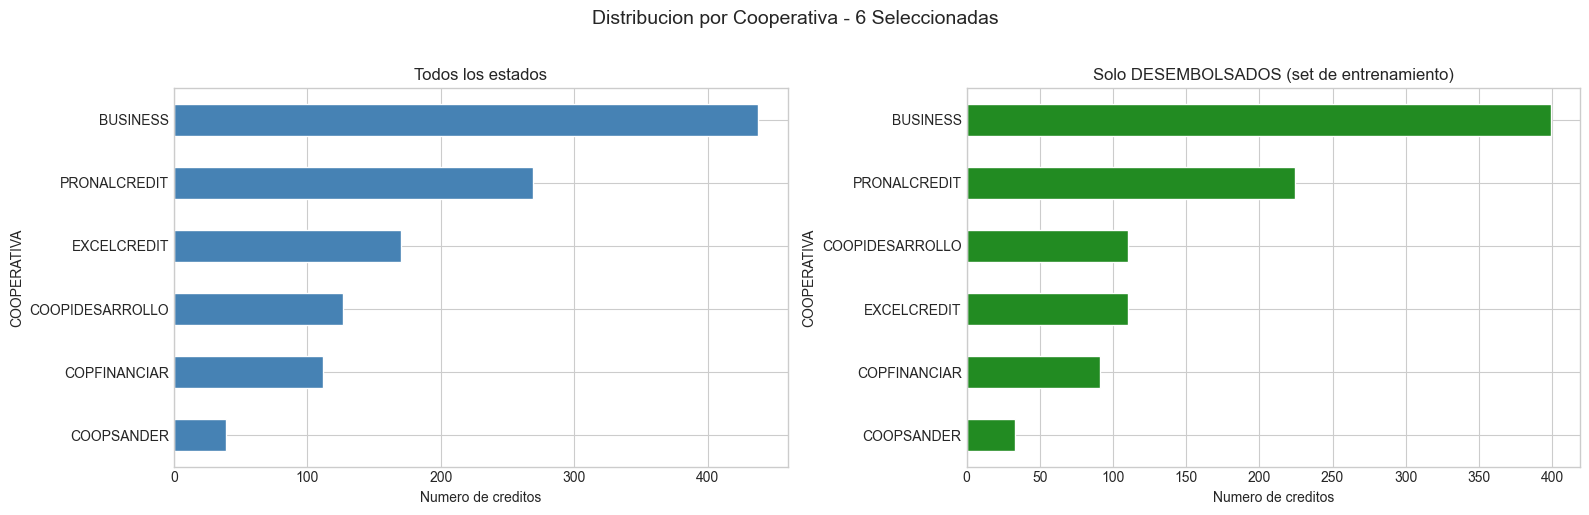

Registros desembolsados en las 6 coops: 967


In [4]:
COOPS_OBJETIVO = {'BUSINESS', 'COOPIDESARROLLO', 'COOPSANDER',
                  'COPFINANCIAR', 'EXCELCREDIT', 'PRONALCREDIT'}

df_sel = df[
    (df['COOPERATIVA'].notna()) &
    (df['ESTADO'] == 'DESEMBOLSADO') &
    df['COOPERATIVA'].isin(COOPS_OBJETIVO)
].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

cnt_all = df[df['COOPERATIVA'].isin(COOPS_OBJETIVO)]['COOPERATIVA'].value_counts()
cnt_all.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Todos los estados', fontsize=12)
axes[0].set_xlabel('Numero de creditos')
axes[0].invert_yaxis()

cnt_desemb = df_sel['COOPERATIVA'].value_counts()
cnt_desemb.plot(kind='barh', ax=axes[1], color='forestgreen', edgecolor='white')
axes[1].set_title('Solo DESEMBOLSADOS (set de entrenamiento)', fontsize=12)
axes[1].set_xlabel('Numero de creditos')
axes[1].invert_yaxis()

plt.suptitle('Distribucion por Cooperativa - 6 Seleccionadas', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{IMG_DIR}/01_distribucion_cooperativas.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Registros desembolsados en las 6 coops: {len(df_sel)}')

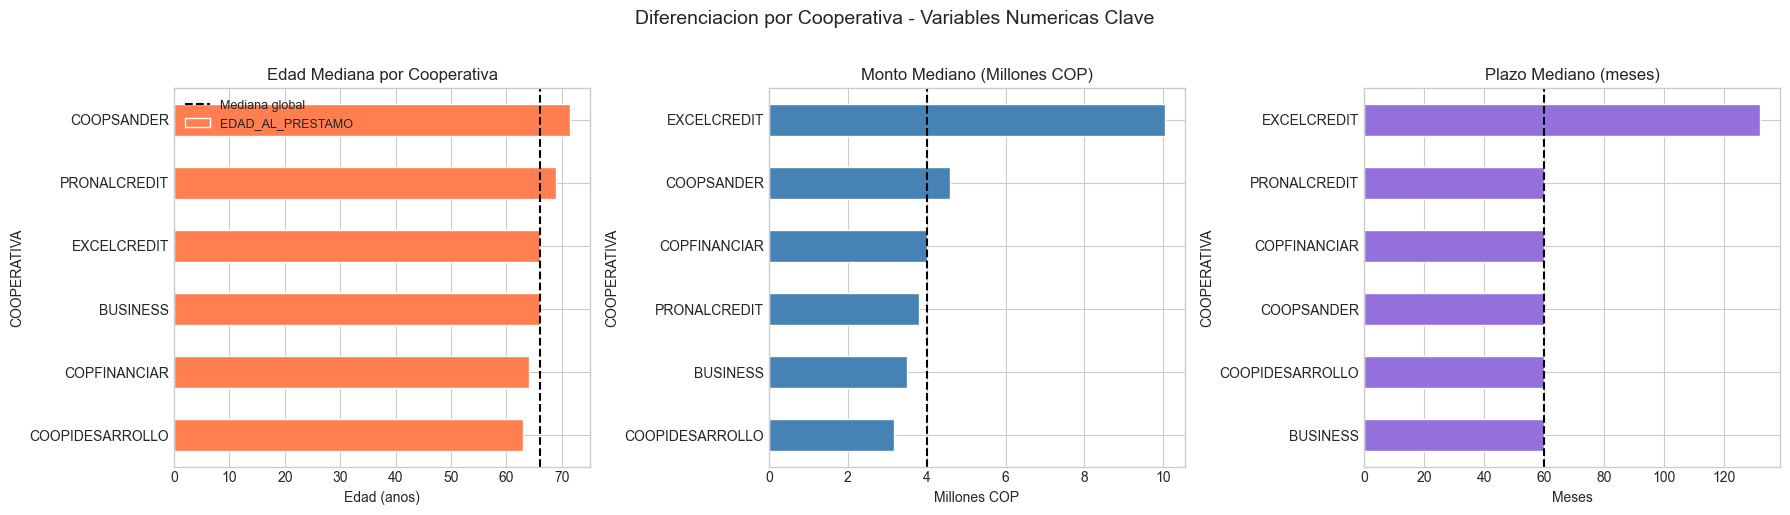

Resumen estadistico:


,Registros,Edad_Med,Monto_Med_M,Plazo_Med
COOPERATIVA,,,,
BUSINESS,399,66.00,3.50,60.00
PRONALCREDIT,224,69.00,3.80,60.00
COOPIDESARROLLO,110,63.00,3.20,60.00
EXCELCREDIT,108,66.00,10.00,132.00
COPFINANCIAR,90,64.00,4.00,60.00
COOPSANDER,32,71.50,4.60,60.00


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

edad_med = df_sel.groupby('COOPERATIVA')['EDAD_AL_PRESTAMO'].median().sort_values()
edad_med.plot(kind='barh', ax=axes[0], color='coral', edgecolor='white')
axes[0].axvline(df_sel['EDAD_AL_PRESTAMO'].median(), color='black', linestyle='--', label='Mediana global')
axes[0].set_title('Edad Mediana por Cooperativa', fontsize=12)
axes[0].set_xlabel('Edad (anos)')
axes[0].legend(fontsize=9)

monto_med = (df_sel.groupby('COOPERATIVA')['MONTO'].median() / 1e6).sort_values()
monto_med.plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].axvline(df_sel['MONTO'].median() / 1e6, color='black', linestyle='--')
axes[1].set_title('Monto Mediano (Millones COP)', fontsize=12)
axes[1].set_xlabel('Millones COP')

plazo_med = df_sel.groupby('COOPERATIVA')['PLAZO'].median().sort_values()
plazo_med.plot(kind='barh', ax=axes[2], color='mediumpurple', edgecolor='white')
axes[2].axvline(df_sel['PLAZO'].median(), color='black', linestyle='--')
axes[2].set_title('Plazo Mediano (meses)', fontsize=12)
axes[2].set_xlabel('Meses')

plt.suptitle('Diferenciacion por Cooperativa - Variables Numericas Clave', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{IMG_DIR}/02_features_por_cooperativa.png', dpi=150, bbox_inches='tight')
plt.show()

print('Resumen estadistico:')
summary = df_sel.groupby('COOPERATIVA').agg(
    Registros=('MONTO', 'count'),
    Edad_Med=('EDAD_AL_PRESTAMO', 'median'),
    Monto_Med_M=('MONTO', lambda x: round(x.median()/1e6, 1)),
    Plazo_Med=('PLAZO', 'median')
).sort_values('Registros', ascending=False)
display(summary)

---
## 3. Preparacion de Features

| Decision | Justificacion |
|---|---|
| Solo 6 cooperativas seleccionadas | Foco en entidades activas con mayor volumen |
| Sin clase OTRAS | Con 6 clases definidas no se necesita agrupacion residual |
| Solo registros DESEMBOLSADO | Aprendemos de colocaciones exitosas |
| `class_weight='balanced'` | BUSINESS domina ~40%; balanceo evita sesgo |

In [6]:
# Cooperativas inactivas (nombre normalizado sin espacio)
COOPS_INACTIVAS = {'BAYPORT', 'VIVECREDITO'}

# Las 6 cooperativas del modelo
COOPS_OBJETIVO = {'BUSINESS', 'COOPIDESARROLLO', 'COOPSANDER',
                  'COPFINANCIAR', 'EXCELCREDIT', 'PRONALCREDIT'}

df_p2 = df[
    (df['COOPERATIVA'].notna()) &
    (df['ESTADO'] == 'DESEMBOLSADO') &
    df['MONTO'].notna() &
    df['PLAZO'].notna() &
    df['COOPERATIVA'].isin(COOPS_OBJETIVO)
].copy()

df_p2['TARGET'] = df_p2['COOPERATIVA']  # sin agrupacion en OTRAS

print(f'Registros para entrenamiento: {len(df_p2)}')
print(f'Cooperativas inactivas excluidas: {COOPS_INACTIVAS}')
print(f'\nClases en el modelo ({df_p2["TARGET"].nunique()} cooperativas):')
dist = df_p2['TARGET'].value_counts()
for coop, cnt in dist.items():
    pct = cnt / len(df_p2) * 100
    print(f'  {coop:<22s}: {cnt:4d} ({pct:.1f}%)')

Registros para entrenamiento: 961
Cooperativas inactivas excluidas: {'VIVECREDITO', 'BAYPORT'}

Clases en el modelo (6 cooperativas):
  BUSINESS              :  399 (41.5%)
  PRONALCREDIT          :  224 (23.3%)
  COOPIDESARROLLO       :  108 (11.2%)
  EXCELCREDIT           :  108 (11.2%)
  COPFINANCIAR          :   90 (9.4%)
  COOPSANDER            :   32 (3.3%)


In [7]:
FEATURES_NUM = ['EDAD_AL_PRESTAMO', 'MONTO', 'PLAZO']
FEATURES_CAT = ['TIPO DE CREDITO', 'PAGADURIA']
ALL_FEATURES  = FEATURES_NUM + FEATURES_CAT
TARGET_COL    = 'TARGET'

df_model = df_p2[ALL_FEATURES + [TARGET_COL]].copy()

for col in FEATURES_NUM:
    df_model[col] = df_model[col].fillna(df_model[col].median())
for col in FEATURES_CAT:
    df_model[col] = df_model[col].fillna('DESCONOCIDO')

print(f'Nulos restantes: {df_model.isnull().sum().sum()}')

le_target = LabelEncoder()
y = le_target.fit_transform(df_model[TARGET_COL])
N_CLASES = len(le_target.classes_)
print(f'Clases ({N_CLASES}): {list(le_target.classes_)}')

le_tipo = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
le_pag  = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

X = df_model[ALL_FEATURES].copy()
X['TIPO DE CREDITO'] = le_tipo.fit_transform(X[['TIPO DE CREDITO']]).ravel()
X['PAGADURIA']       = le_pag.fit_transform(X[['PAGADURIA']]).ravel()

print(f'Shape X: {X.shape}  |  Shape y: {y.shape}')

Nulos restantes: 0
Clases (6): ['BUSINESS', 'COOPIDESARROLLO', 'COOPSANDER', 'COPFINANCIAR', 'EXCELCREDIT', 'PRONALCREDIT']
Shape X: (961, 5)  |  Shape y: (961,)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
RESULTADOS = []

def registrar(nombre, variante, acc, f1):
    RESULTADOS.append({'Modelo': nombre, 'Variante': variante,
                       'Accuracy': round(acc, 4), 'F1_weighted': round(f1, 4)})
    print(f'  {variante:<14s}  Accuracy={acc:.4f}  F1={f1:.4f}')

Train: (768, 5)  |  Test: (193, 5)


---
## 4. Arbol de Decision

Hiperparametros: max_depth [3,5,7,10,None] - min_samples_split [2,5,10,20] - min_samples_leaf [1,2,5,10] - criterion [gini,entropy]  
Total: **160 combinaciones x 5 folds = 800 fits**

In [9]:
print('=' * 60)
print('  MODELO 1: ARBOL DE DECISION')
print('=' * 60)

dt_base = DecisionTreeClassifier(random_state=42, class_weight='balanced')
dt_base.fit(X_train, y_train)
y_pred_dt_b = dt_base.predict(X_test)
registrar('Arbol Decision', 'baseline',
          accuracy_score(y_test, y_pred_dt_b), f1_score(y_test, y_pred_dt_b, average='weighted'))
print(f'  Profundidad: {dt_base.get_depth()}  |  Hojas: {dt_base.get_n_leaves()}')

param_grid_dt = {
    'max_depth':          [3, 5, 7, 10, None],
    'min_samples_split':  [2, 5, 10, 20],
    'min_samples_leaf':   [1, 2, 5, 10],
    'criterion':          ['gini', 'entropy']
}
grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    param_grid_dt, cv=cv, scoring='f1_weighted', n_jobs=-1, verbose=1
)
grid_dt.fit(X_train, y_train)
print(f'\nMejores parametros DT: {grid_dt.best_params_}')
print(f'F1 CV: {grid_dt.best_score_:.4f}')

dt_opt = grid_dt.best_estimator_
y_pred_dt = dt_opt.predict(X_test)
registrar('Arbol Decision', 'optimizado',
          accuracy_score(y_test, y_pred_dt), f1_score(y_test, y_pred_dt, average='weighted'))

  MODELO 1: ARBOL DE DECISION
  baseline        Accuracy=0.5648  F1=0.5571
  Profundidad: 23  |  Hojas: 333
Fitting 5 folds for each of 160 candidates, totalling 800 fits

Mejores parametros DT: {'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 2}
F1 CV: 0.5438
  optimizado      Accuracy=0.5337  F1=0.5442


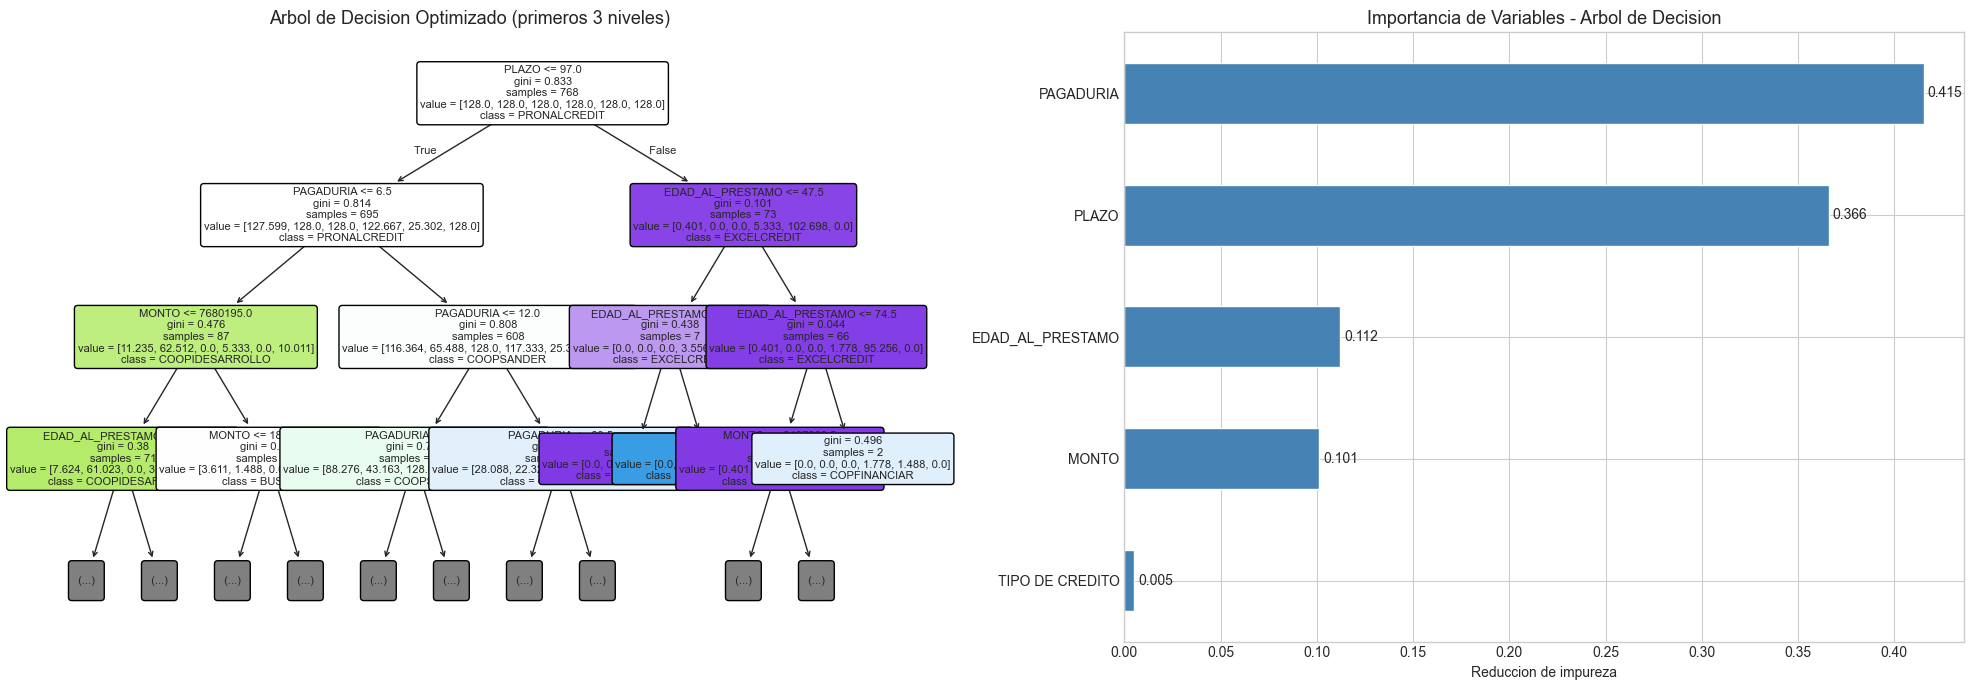


Reglas del arbol (primeros 3 niveles):
|--- PLAZO <= 97.00
|   |--- PAGADURIA <= 6.50
|   |   |--- MONTO <= 7680195.00
|   |   |   |--- EDAD_AL_PRESTAMO <= 38.00
|   |   |   |   |--- class: 5
|   |   |   |--- EDAD_AL_PRESTAMO >  38.00
|   |   |   |   |--- truncated branch of depth 4
|   |   |--- MONTO >  7680195.00
|   |   |   |--- MONTO <= 18900000.00
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- MONTO >  18900000.00
|   |   |   |   |--- truncated branch of depth 2
|   |--- PAGADURIA >  6.50
|   |   |--- PAGADURIA <= 12.00
|   |   |   |--- PAGADURIA <= 9.50
|   |   |   |   |--- truncated branch of depth 4
|   |   |   |--- PAGADURIA >  9.50
|   |   |   |   |--- truncated branch of depth 4
|   |   |--- PAGADURIA >  12.00
|   |   |   |--- PAGADURIA <= 23.50
|   |   |   |   |--- truncated branch of depth 4
|   |   |   |--- PAGADURIA >  23.50
|   |   |   |   |--- truncated branch of depth 4
|--- PLAZO >  97.00
|   |--- EDAD_AL_PRESTAMO <= 47.50
|   |   |--- EDAD_AL_PRE

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

plot_tree(dt_opt, feature_names=ALL_FEATURES, class_names=le_target.classes_,
          filled=True, rounded=True, max_depth=3, fontsize=8, ax=axes[0])
axes[0].set_title('Arbol de Decision Optimizado (primeros 3 niveles)', fontsize=13)

imp_dt = pd.Series(dt_opt.feature_importances_, index=ALL_FEATURES).sort_values()
imp_dt.plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Importancia de Variables - Arbol de Decision', fontsize=13)
axes[1].set_xlabel('Reduccion de impureza')
for i, v in enumerate(imp_dt):
    axes[1].text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig(f'{IMG_DIR}/03_arbol_decision.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nReglas del arbol (primeros 3 niveles):')
print(export_text(dt_opt, feature_names=ALL_FEATURES, max_depth=3))

---
## 5. Random Forest

Hiperparametros: n_estimators [100,200,300] - max_depth [10,15,20,None] - min_samples_leaf [1,2,4] - max_features [sqrt,log2]  
Total: **72 combinaciones x 5 folds = 360 fits**

  MODELO 2: RANDOM FOREST
  baseline        Accuracy=0.6269  F1=0.6036
Fitting 5 folds for each of 72 candidates, totalling 360 fits

Mejores parametros RF: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 200}
F1 CV: 0.6430
  optimizado      Accuracy=0.6062  F1=0.5949


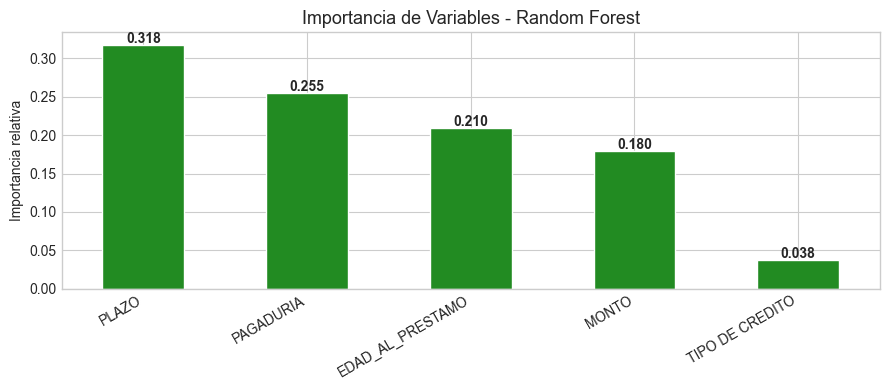

In [11]:
print('=' * 60)
print('  MODELO 2: RANDOM FOREST')
print('=' * 60)

rf_base = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)
rf_base.fit(X_train, y_train)
y_pred_rf_b = rf_base.predict(X_test)
registrar('Random Forest', 'baseline',
          accuracy_score(y_test, y_pred_rf_b), f1_score(y_test, y_pred_rf_b, average='weighted'))

param_grid_rf = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [10, 15, 20, None],
    'min_samples_leaf': [1, 2, 4],
    'max_features':     ['sqrt', 'log2']
}
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1),
    param_grid_rf, cv=cv, scoring='f1_weighted', n_jobs=-1, verbose=1
)
grid_rf.fit(X_train, y_train)
print(f'\nMejores parametros RF: {grid_rf.best_params_}')
print(f'F1 CV: {grid_rf.best_score_:.4f}')

rf_opt = grid_rf.best_estimator_
y_pred_rf = rf_opt.predict(X_test)
registrar('Random Forest', 'optimizado',
          accuracy_score(y_test, y_pred_rf), f1_score(y_test, y_pred_rf, average='weighted'))

imp_rf = pd.Series(rf_opt.feature_importances_, index=ALL_FEATURES).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 4))
imp_rf.plot(kind='bar', ax=ax, color='forestgreen', edgecolor='white')
ax.set_title('Importancia de Variables - Random Forest', fontsize=13)
ax.set_ylabel('Importancia relativa')
plt.xticks(rotation=30, ha='right')
for i, v in enumerate(imp_rf):
    ax.text(i, v + 0.002, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{IMG_DIR}/04_importancia_rf.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Gradient Boosting

Hiperparametros: n_estimators [100,200] - learning_rate [0.05,0.1,0.2] - max_depth [3,5,7] - min_samples_split [2,5] - subsample [0.8,1.0]  
Total: **72 combinaciones x 5 folds = 360 fits**

In [12]:
print('=' * 60)
print('  MODELO 3: GRADIENT BOOSTING')
print('=' * 60)

gb_base = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_base.fit(X_train, y_train)
y_pred_gb_b = gb_base.predict(X_test)
registrar('Gradient Boosting', 'baseline',
          accuracy_score(y_test, y_pred_gb_b), f1_score(y_test, y_pred_gb_b, average='weighted'))

param_grid_gb = {
    'n_estimators':      [100, 200],
    'learning_rate':     [0.05, 0.1, 0.2],
    'max_depth':         [3, 5, 7],
    'min_samples_split': [2, 5],
    'subsample':         [0.8, 1.0]
}
grid_gb = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid_gb, cv=cv, scoring='f1_weighted', n_jobs=-1, verbose=1
)
grid_gb.fit(X_train, y_train)
print(f'\nMejores parametros GB: {grid_gb.best_params_}')
print(f'F1 CV: {grid_gb.best_score_:.4f}')

gb_opt = grid_gb.best_estimator_
y_pred_gb = gb_opt.predict(X_test)
registrar('Gradient Boosting', 'optimizado',
          accuracy_score(y_test, y_pred_gb), f1_score(y_test, y_pred_gb, average='weighted'))

  MODELO 3: GRADIENT BOOSTING
  baseline        Accuracy=0.6373  F1=0.6107
Fitting 5 folds for each of 72 candidates, totalling 360 fits

Mejores parametros GB: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 200, 'subsample': 1.0}
F1 CV: 0.6813
  optimizado      Accuracy=0.6425  F1=0.6204


---
## 7. K-Nearest Neighbors

Hiperparametros: n_neighbors [3,5,7,10,15,20] - weights [uniform,distance] - metric [euclidean,manhattan]  
Total: **24 combinaciones x 5 folds = 120 fits**

In [13]:
print('=' * 60)
print('  MODELO 4: K-NEAREST NEIGHBORS  (datos escalados)')
print('=' * 60)

knn_base = KNeighborsClassifier(n_neighbors=5)
knn_base.fit(X_train_sc, y_train)
y_pred_knn_b = knn_base.predict(X_test_sc)
registrar('KNN', 'baseline (k=5)',
          accuracy_score(y_test, y_pred_knn_b), f1_score(y_test, y_pred_knn_b, average='weighted'))

param_grid_knn = {
    'n_neighbors': [3, 5, 7, 10, 15, 20],
    'weights':     ['uniform', 'distance'],
    'metric':      ['euclidean', 'manhattan']
}
grid_knn = GridSearchCV(
    KNeighborsClassifier(), param_grid_knn,
    cv=cv, scoring='f1_weighted', n_jobs=-1, verbose=1
)
grid_knn.fit(X_train_sc, y_train)
print(f'\nMejores parametros KNN: {grid_knn.best_params_}')
print(f'F1 CV: {grid_knn.best_score_:.4f}')

knn_opt = grid_knn.best_estimator_
y_pred_knn = knn_opt.predict(X_test_sc)
registrar('KNN', 'optimizado',
          accuracy_score(y_test, y_pred_knn), f1_score(y_test, y_pred_knn, average='weighted'))

  MODELO 4: K-NEAREST NEIGHBORS  (datos escalados)
  baseline (k=5)  Accuracy=0.5544  F1=0.4978
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Mejores parametros KNN: {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'distance'}
F1 CV: 0.5711
  optimizado      Accuracy=0.5907  F1=0.5542


---
## 8. XGBoost

Hiperparametros: n_estimators [100,200] - learning_rate [0.05,0.1] - max_depth [3,5,7] - subsample [0.8,1.0] - colsample_bytree [0.8,1.0]  
Total: **48 combinaciones x 5 folds = 240 fits**

In [14]:
if XGBOOST_AVAILABLE:
    print('=' * 60)
    print('  MODELO 5: XGBOOST')
    print('=' * 60)

    xgb_base = XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss', verbosity=0)
    xgb_base.fit(X_train, y_train)
    y_pred_xgb_b = xgb_base.predict(X_test)
    registrar('XGBoost', 'baseline',
              accuracy_score(y_test, y_pred_xgb_b), f1_score(y_test, y_pred_xgb_b, average='weighted'))

    param_grid_xgb = {
        'n_estimators':     [100, 200],
        'learning_rate':    [0.05, 0.1],
        'max_depth':        [3, 5, 7],
        'subsample':        [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0]
    }
    grid_xgb = GridSearchCV(
        XGBClassifier(random_state=42, eval_metric='mlogloss', verbosity=0),
        param_grid_xgb, cv=cv, scoring='f1_weighted', n_jobs=-1, verbose=1
    )
    grid_xgb.fit(X_train, y_train)
    print(f'\nMejores parametros XGBoost: {grid_xgb.best_params_}')
    print(f'F1 CV: {grid_xgb.best_score_:.4f}')

    xgb_opt = grid_xgb.best_estimator_
    y_pred_xgb = xgb_opt.predict(X_test)
    registrar('XGBoost', 'optimizado',
              accuracy_score(y_test, y_pred_xgb), f1_score(y_test, y_pred_xgb, average='weighted'))
else:
    print('XGBoost no disponible -- pip install xgboost')

  MODELO 5: XGBOOST
  baseline        Accuracy=0.6425  F1=0.6274
Fitting 5 folds for each of 48 candidates, totalling 240 fits

Mejores parametros XGBoost: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 200, 'subsample': 1.0}
F1 CV: 0.6739
  optimizado      Accuracy=0.6269  F1=0.6008


---
## 9. Comparacion de Modelos

TABLA COMPARATIVA DE MODELOS
               Modelo        Variante  Accuracy  F1_weighted
1             XGBoost        baseline      0.64         0.63
2   Gradient Boosting      optimizado      0.64         0.62
3   Gradient Boosting        baseline      0.64         0.61
4       Random Forest        baseline      0.63         0.60
5             XGBoost      optimizado      0.63         0.60
6       Random Forest      optimizado      0.61         0.59
7      Arbol Decision        baseline      0.56         0.56
8                 KNN      optimizado      0.59         0.55
9      Arbol Decision      optimizado      0.53         0.54
10                KNN  baseline (k=5)      0.55         0.50


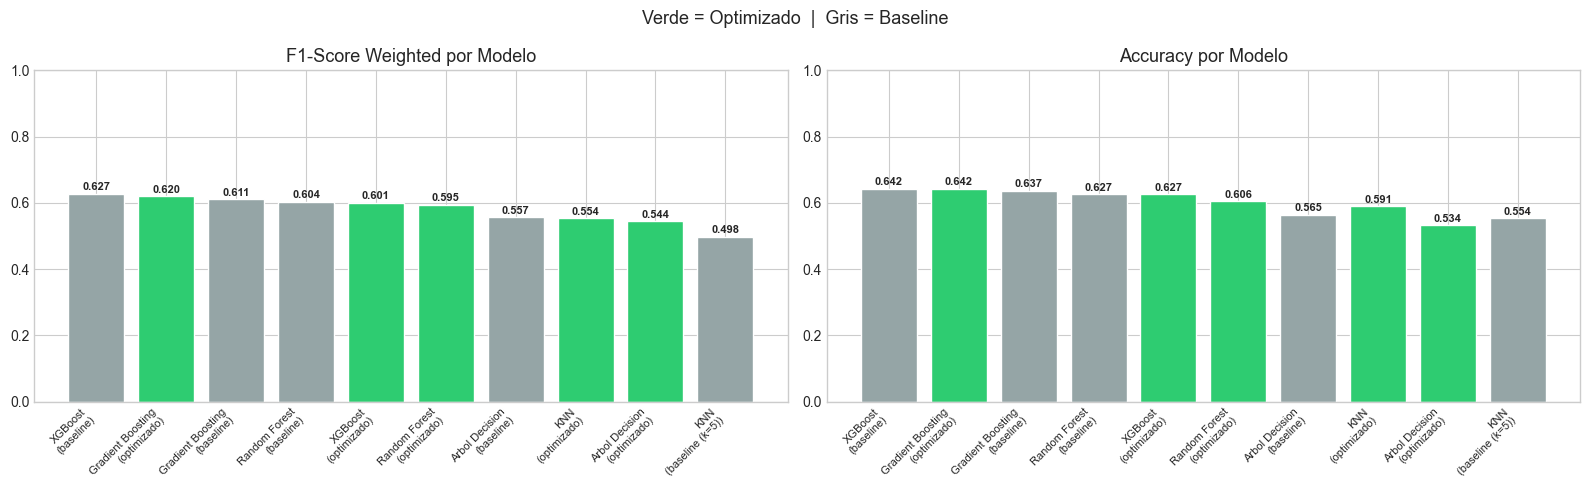

In [15]:
df_res = pd.DataFrame(RESULTADOS).sort_values('F1_weighted', ascending=False).reset_index(drop=True)
df_res.index += 1
print('TABLA COMPARATIVA DE MODELOS')
print('=' * 55)
print(df_res.to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
palette = ['#2ecc71' if 'optimizado' in str(v).lower() else '#95a5a6' for v in df_res['Variante']]
labels  = df_res['Modelo'] + '\n(' + df_res['Variante'] + ')'

for ax, col, titulo in zip(axes, ['F1_weighted', 'Accuracy'], ['F1-Score Weighted', 'Accuracy']):
    ax.bar(range(len(df_res)), df_res[col], color=palette, edgecolor='white')
    ax.set_xticks(range(len(df_res)))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    ax.set_title(f'{titulo} por Modelo', fontsize=13)
    ax.set_ylim(0, 1)
    for i, v in enumerate(df_res[col]):
        ax.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=8, fontweight='bold')

plt.suptitle('Verde = Optimizado  |  Gris = Baseline', fontsize=13)
plt.tight_layout()
plt.savefig(f'{IMG_DIR}/05_comparacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
df_opt = df_res[df_res['Variante'] == 'optimizado'].sort_values('F1_weighted', ascending=False)
mejor_nombre_base = df_opt.iloc[0]['Modelo']

modelo_map = {
    'Arbol Decision':    (dt_opt,  y_pred_dt),
    'Random Forest':     (rf_opt,  y_pred_rf),
    'Gradient Boosting': (gb_opt,  y_pred_gb),
    'KNN':               (knn_opt, y_pred_knn),
}
if XGBOOST_AVAILABLE:
    modelo_map['XGBoost'] = (xgb_opt, y_pred_xgb)

mejor_modelo, y_pred_mejor = modelo_map[mejor_nombre_base]

from sklearn.neighbors import KNeighborsClassifier as _KNN
X_test_mejor = X_test_sc if isinstance(mejor_modelo, _KNN) else X_test

print(f'MEJOR MODELO: {mejor_nombre_base}')
print(f'Accuracy:     {accuracy_score(y_test, y_pred_mejor):.4f}')
print(f'F1 weighted:  {f1_score(y_test, y_pred_mejor, average="weighted"):.4f}')
print()
print(classification_report(y_test, y_pred_mejor,
      target_names=le_target.classes_, zero_division=0))

MEJOR MODELO: Gradient Boosting
Accuracy:     0.6425
F1 weighted:  0.6204

                 precision    recall  f1-score   support

       BUSINESS       0.67      0.90      0.77        80
COOPIDESARROLLO       0.37      0.32      0.34        22
     COOPSANDER       1.00      0.33      0.50         6
   COPFINANCIAR       0.33      0.17      0.22        18
    EXCELCREDIT       1.00      0.82      0.90        22
   PRONALCREDIT       0.59      0.49      0.54        45

       accuracy                           0.64       193
      macro avg       0.66      0.50      0.54       193
   weighted avg       0.63      0.64      0.62       193



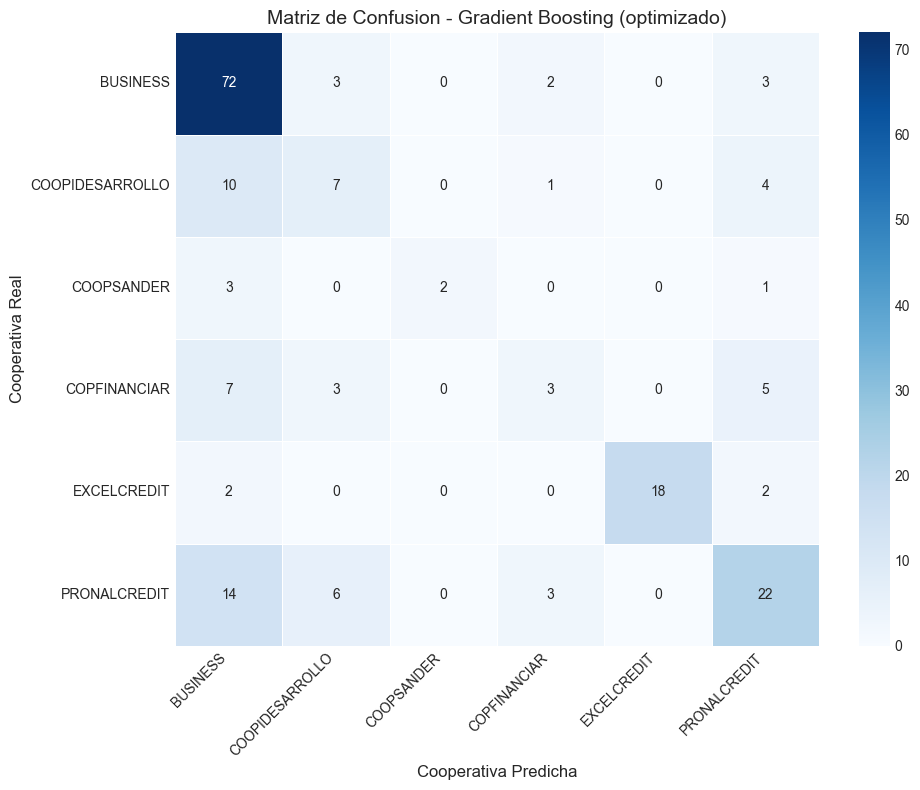

Top-1 Accuracy: 0.6425
Top-3 Accuracy: 0.8912
Top-5 Accuracy: 0.9845


In [17]:
cm = confusion_matrix(y_test, y_pred_mejor)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, xticklabels=le_target.classes_, yticklabels=le_target.classes_,
            annot=True, fmt='d', cmap='Blues', linewidths=0.5, ax=ax)
ax.set_title(f'Matriz de Confusion - {mejor_nombre_base} (optimizado)', fontsize=14)
ax.set_xlabel('Cooperativa Predicha', fontsize=12)
ax.set_ylabel('Cooperativa Real', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{IMG_DIR}/06_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

try:
    y_proba = mejor_modelo.predict_proba(X_test_mejor)
    top3 = top_k_accuracy_score(y_test, y_proba, k=3)
    top5 = top_k_accuracy_score(y_test, y_proba, k=min(5, N_CLASES))
    print(f'Top-1 Accuracy: {accuracy_score(y_test, y_pred_mejor):.4f}')
    print(f'Top-3 Accuracy: {top3:.4f}')
    print(f'Top-5 Accuracy: {top5:.4f}')
except Exception as e:
    print(f'Top-k no disponible: {e}')

---
## 10. MVP -- Funcion de Recomendacion (solo ML)

Recomendacion basada unicamente en probabilidades del modelo, sin filtro de reglas.
Ver seccion 11 para el pipeline completo con reglas de negocio.

In [18]:
def recomendar_cooperativa(edad, monto, plazo, tipo_credito, pagaduria,
                            top_n=3, modelo=None):
    # Recomienda top-N cooperativas por probabilidad ML
    if modelo is None:
        modelo = mejor_modelo

    def _norm(s):
        s = str(s).upper().strip()
        s = unicodedata.normalize('NFD', s)
        s = ''.join(c for c in s if unicodedata.category(c) != 'Mn')
        return re.sub(r'\s+', ' ', s).strip()

    X_new = pd.DataFrame({
        'EDAD_AL_PRESTAMO': [float(edad)],
        'MONTO':            [float(monto)],
        'PLAZO':            [float(plazo)],
        'TIPO DE CREDITO':  [_norm(tipo_credito)],
        'PAGADURIA':        [_norm(pagaduria)]
    })
    X_new['TIPO DE CREDITO'] = le_tipo.transform(X_new[['TIPO DE CREDITO']]).ravel()
    X_new['PAGADURIA']       = le_pag.transform(X_new[['PAGADURIA']]).ravel()

    from sklearn.neighbors import KNeighborsClassifier as _KNN
    X_input = scaler.transform(X_new) if isinstance(modelo, _KNN) else X_new

    probs   = modelo.predict_proba(X_input)[0]
    top_idx = np.argsort(probs)[::-1][:top_n]

    return pd.DataFrame({
        'Ranking':      range(1, top_n + 1),
        'Cooperativa':  le_target.inverse_transform(top_idx),
        'Probabilidad': probs[top_idx].round(4),
        'Confianza':    [f'{p*100:.1f}%' for p in probs[top_idx]]
    })

print('recomendar_cooperativa() definida')

recomendar_cooperativa() definida


In [19]:
artefactos = {
    'mejor_modelo':     mejor_modelo,
    'mejor_nombre':     mejor_nombre_base,
    'dt_opt':           dt_opt,
    'rf_opt':           rf_opt,
    'gb_opt':           gb_opt,
    'knn_opt':          knn_opt,
    'le_target':        le_target,
    'le_tipo':          le_tipo,
    'le_pag':           le_pag,
    'scaler':           scaler,
    'features':         ALL_FEATURES,
    'clases':           list(le_target.classes_),
    'resultados_tabla': RESULTADOS,
    'fecha_train':      datetime.now().isoformat(),
    'coops_objetivo':   list(COOPS_OBJETIVO),
    'coops_inactivas':  list(COOPS_INACTIVAS),
}
if XGBOOST_AVAILABLE:
    artefactos['xgb_opt'] = xgb_opt

with open('../modelos/modelo2_Gradient_Boosting.pkl', 'wb') as f:
    pickle.dump(artefactos, f)

print('Modelos guardados en modelos_Gradient_Boosting.pkl')
print(f'  Mejor modelo : {mejor_nombre_base}')
print(f'  Clases ({len(le_target.classes_)}): {list(le_target.classes_)}')

Modelos guardados en modelos_Gradient_Boosting.pkl
  Mejor modelo : Gradient Boosting
  Clases (6): ['BUSINESS', 'COOPIDESARROLLO', 'COOPSANDER', 'COPFINANCIAR', 'EXCELCREDIT', 'PRONALCREDIT']


---
## 11. Sistema de Dos Etapas: Reglas de Negocio + ML

| Etapa | Metodo | Pregunta |
|-------|--------|----------|
| **1 - Filtro de reglas** | Programacion convencional | El cliente *puede* acceder a esta cooperativa? |
| **2 - Ranking ML** | Modelo entrenado | En cual tiene mas probabilidades de aprobacion? |

### Reglas por cooperativa

| Cooperativa | Fuente de reglas |
|---|---|
| **BUSINESS** | Reglas Business.pdf |
| **EXCELCREDIT** | Reglas ExcelCredit.pdf |
| **COPFINANCIAR** | Reglas copfinanciar.doc |
| **PRONALCREDIT** | Mismas reglas que COPFINANCIAR |
| **COOPIDESARROLLO** | Mismas reglas que COPFINANCIAR |
| **COOPSANDER** | Sin reglas documentadas -- pasa Stage 1 siempre |

### Reglas comunes (COPFINANCIAR / PRONALCREDIT / COOPIDESARROLLO)
- Pagaduria debe ser pension publica (COLPENSIONES, FOPEP, FIDUPREVISORA, etc.)
- Edad maxima 75 anos
- Credito nuevo: plazo 12-48 meses
- Refinanciacion: plazo 12-60 meses

In [20]:
# ETAPA 1: Reglas de negocio por cooperativa

# Pagadurias validas para las 3 cooperativas de pension publica
PAGADURIAS_PENSION = {
    'COLPENSIONES', 'ARP POSITIVA', 'FOPEP',
    'FONDO DE PENSIONES PUBLICAS FOPEP',
    'FIDUPREVISORA', 'EJERCITO NACIONAL'
}


def _elegibilidad_business(edad, monto, plazo, tipo):
    # Reglas Business Integrals SAS (Reglas Business.pdf)
    razones = []
    if edad < 18 or edad > 84:
        razones.append(f'Edad {edad} fuera del rango permitido (18-84 anos)')
        return False, razones
    if tipo != 'REFINANCIACION' and plazo < 49:
        razones.append(f'Plazo {plazo}m menor al minimo para credito nuevo (49m)')
    if edad <= 75:
        if monto > 30_000_000:
            razones.append(f'Monto ${monto:,.0f} supera limite 18-75 anos ($30.000.000)')
        if plazo > 96:
            razones.append(f'Plazo {plazo}m supera limite 18-75 anos (96m)')
    elif edad <= 80:
        if monto > 20_000_000:
            razones.append(f'Monto ${monto:,.0f} supera limite 76-80 anos ($20.000.000)')
        if plazo > 96:
            razones.append(f'Plazo {plazo}m supera limite 76-80 anos (96m)')
    else:
        if monto > 15_000_000:
            razones.append(f'Monto ${monto:,.0f} supera limite 81-84 anos ($15.000.000)')
        if plazo > 72:
            razones.append(f'Plazo {plazo}m supera limite 81-84 anos (72m)')
    return len(razones) == 0, razones


def _elegibilidad_excelcredit(edad, monto, plazo, tipo):
    # Reglas ExcelCredit (Reglas ExcelCredit.pdf) - politica pensionados
    razones = []
    if edad < 20 or edad > 81:
        razones.append(f'Edad {edad} fuera del rango permitido (20-81 anos)')
        return False, razones
    if monto < 1_500_000:
        razones.append(f'Monto ${monto:,.0f} menor al minimo ($1.500.000)')
    if plazo < 12:
        razones.append(f'Plazo {plazo}m menor al minimo (12m)')
    _tabla = [
        (20, 69, 144, 115_000_000),
        (70, 73, 144, 100_000_000),
        (74, 74, 108, 100_000_000),
        (75, 75,  96, 100_000_000),
        (76, 76,  84,  65_000_000),
        (77, 77,  72,  65_000_000),
        (78, 78,  60,  65_000_000),
        (79, 79,  48,  65_000_000),
        (80, 81,  36,  13_000_000),
    ]
    for min_e, max_e, max_p, max_m in _tabla:
        if min_e <= edad <= max_e:
            if plazo > max_p:
                razones.append(f'Plazo {plazo}m supera limite para edad {edad} ({max_p}m)')
            if monto > max_m:
                razones.append(f'Monto ${monto:,.0f} supera limite para edad {edad} (${max_m:,.0f})')
            break
    return len(razones) == 0, razones


def _elegibilidad_coops_pension(edad, monto, plazo, tipo, pagaduria):
    # Reglas compartidas por COPFINANCIAR, PRONALCREDIT y COOPIDESARROLLO
    # Basadas en Reglas copfinanciar.doc
    razones = []
    pag_ok = any(p in pagaduria for p in PAGADURIAS_PENSION)
    if not pag_ok:
        razones.append(f'Pagaduria "{pagaduria}" no cubierta (requiere pension publica)')
    if tipo != 'REFINANCIACION':
        if edad > 75:
            razones.append(f'Edad {edad} supera maximo para credito nuevo (75 anos)')
        if plazo < 12 or plazo > 48:
            razones.append(f'Plazo {plazo}m fuera del rango permitido (12-48m)')
    else:
        if edad > 75:
            razones.append(f'Edad {edad} supera maximo para refinanciacion (75 anos)')
        if plazo < 12 or plazo > 60:
            razones.append(f'Plazo {plazo}m fuera del rango para refinanciacion (12-60m)')
    return len(razones) == 0, razones


def filtrar_stage1(edad, monto, plazo, tipo_credito, pagaduria):
    # Evalua elegibilidad para las 5 coops con reglas documentadas.
    # COOPSANDER no tiene restricciones: no aparece en el dict y nunca se bloquea.
    ok_b,  r_b  = _elegibilidad_business(edad, monto, plazo, tipo_credito)
    ok_e,  r_e  = _elegibilidad_excelcredit(edad, monto, plazo, tipo_credito)
    ok_cp, r_cp = _elegibilidad_coops_pension(edad, monto, plazo, tipo_credito, pagaduria)
    return {
        'BUSINESS':        {'elegible': ok_b,  'razones': r_b},
        'EXCELCREDIT':     {'elegible': ok_e,  'razones': r_e},
        'COPFINANCIAR':    {'elegible': ok_cp, 'razones': r_cp},
        'PRONALCREDIT':    {'elegible': ok_cp, 'razones': list(r_cp)},
        'COOPIDESARROLLO': {'elegible': ok_cp, 'razones': list(r_cp)},
    }


print('Etapa 1 definida: filtrar_stage1()')
print('  - _elegibilidad_business()      -> BUSINESS')
print('  - _elegibilidad_excelcredit()   -> EXCELCREDIT')
print('  - _elegibilidad_coops_pension() -> COPFINANCIAR / PRONALCREDIT / COOPIDESARROLLO')
print('  - COOPSANDER: sin restricciones documentadas')

Etapa 1 definida: filtrar_stage1()
  - _elegibilidad_business()      -> BUSINESS
  - _elegibilidad_excelcredit()   -> EXCELCREDIT
  - _elegibilidad_coops_pension() -> COPFINANCIAR / PRONALCREDIT / COOPIDESARROLLO
  - COOPSANDER: sin restricciones documentadas


In [21]:
def recomendar_con_filtros(edad, monto, plazo, tipo_credito, pagaduria,
                            top_n=3, modelo=None, verbose=True):
    # Pipeline de dos etapas:
    #   Etapa 1: Filtro de reglas de negocio (descarta inelegibles).
    #   Etapa 2: Ranking ML sobre los elegibles.
    if modelo is None:
        modelo = mejor_modelo

    def _norm(s):
        s = str(s).upper().strip()
        s = unicodedata.normalize('NFD', s)
        s = ''.join(c for c in s if unicodedata.category(c) != 'Mn')
        return re.sub(r'\s+', ' ', s).strip()

    tipo = _norm(tipo_credito)
    pag  = _norm(pagaduria)

    # Etapa 1
    filtros = filtrar_stage1(edad, monto, plazo, tipo, pag)

    if verbose:
        print('ETAPA 1 -- Filtro de reglas de negocio')
        print('=' * 58)
        for coop, res in filtros.items():
            icono = '[SI]' if res['elegible'] else '[NO]'
            print(f'  {icono} {coop}')
            for r in res['razones']:
                print(f'       -> {r}')
        print('  [SI] COOPSANDER  (sin reglas documentadas)')

    bloqueadas = set(COOPS_INACTIVAS) | {
        coop for coop, res in filtros.items() if not res['elegible']
    }

    # Etapa 2
    X_new = pd.DataFrame({
        'EDAD_AL_PRESTAMO': [float(edad)],
        'MONTO':            [float(monto)],
        'PLAZO':            [float(plazo)],
        'TIPO DE CREDITO':  [tipo],
        'PAGADURIA':        [pag]
    })
    X_new['TIPO DE CREDITO'] = le_tipo.transform(X_new[['TIPO DE CREDITO']]).ravel()
    X_new['PAGADURIA']       = le_pag.transform(X_new[['PAGADURIA']]).ravel()

    from sklearn.neighbors import KNeighborsClassifier as _KNN
    X_input = scaler.transform(X_new) if isinstance(modelo, _KNN) else X_new

    probs  = modelo.predict_proba(X_input)[0]
    clases = le_target.classes_

    candidatos = [
        (coop, prob) for coop, prob in zip(clases, probs)
        if coop not in bloqueadas
    ]
    candidatos.sort(key=lambda x: x[1], reverse=True)

    if not candidatos:
        if verbose:
            print('\n[AVISO] Ningun candidato elegible para este perfil.')
        return pd.DataFrame()

    top = candidatos[:top_n]
    coops_con_reglas_ok = {c for c, r in filtros.items() if r['elegible']}

    def _estado_reglas(c):
        if c == 'COOPSANDER':
            return 'Sin reglas doc.'
        if c in coops_con_reglas_ok:
            return 'OK (documentado)'
        if c in filtros:
            return 'BLOQUEADA'
        return 'Sin reglas doc.'

    resultado = pd.DataFrame({
        'Ranking':     range(1, len(top) + 1),
        'Cooperativa': [c for c, _ in top],
        'Prob_ML':     [round(p, 4) for _, p in top],
        'Confianza':   [f'{p*100:.1f}%' for _, p in top],
        'Reglas':      [_estado_reglas(c) for c, _ in top],
    })

    if verbose:
        print(f'\nETAPA 2 -- Ranking ML (top {top_n})')
        print('=' * 58)
        for _, row in resultado.iterrows():
            print(f"  {int(row['Ranking'])}. {row['Cooperativa']:<22} "
                  f"{row['Confianza']}  [{row['Reglas']}]")

    return resultado


print('Pipeline recomendar_con_filtros() definido.')

Pipeline recomendar_con_filtros() definido.


In [22]:
casos_prueba = [
    {
        'desc': 'Pensionado 60 anos, COLPENSIONES -- debe pasar todas las coops con reglas',
        'edad': 60, 'monto': 8_000_000, 'plazo': 49,
        'tipo': 'LIBRE INVERSION', 'pag': 'COLPENSIONES',
    },
    {
        'desc': 'Pensionado 76 anos -- Business tramo 76-80, ExcelCredit acepta hasta 84m',
        'edad': 76, 'monto': 12_000_000, 'plazo': 60,
        'tipo': 'LIBRE INVERSION', 'pag': 'COLPENSIONES',
    },
    {
        'desc': 'Pensionado 80 anos, plazo 36m -- Coops pension bloqueadas por edad',
        'edad': 80, 'monto': 5_000_000, 'plazo': 36,
        'tipo': 'LIBRE INVERSION', 'pag': 'COLPENSIONES',
    },
    {
        'desc': 'Pensionado 85 anos -- Business y ExcelCredit bloqueados por edad',
        'edad': 85, 'monto': 5_000_000, 'plazo': 36,
        'tipo': 'LIBRE INVERSION', 'pag': 'COLPENSIONES',
    },
    {
        'desc': 'Pagaduria CASUR -- Coops pension bloqueadas (pag. no cubierta)',
        'edad': 60, 'monto': 10_000_000, 'plazo': 49,
        'tipo': 'LIBRE INVERSION', 'pag': 'CASUR',
    },
    {
        'desc': 'Refinanciacion 70 anos Colpensiones -- Coops pension aceptan hasta 60m',
        'edad': 70, 'monto': 6_000_000, 'plazo': 55,
        'tipo': 'REFINANCIACION', 'pag': 'COLPENSIONES',
    },
]

for i, caso in enumerate(casos_prueba, 1):
    sep = '=' * 72
    print(f'\n{sep}')
    print(f'CASO {i}: {caso["desc"]}')
    print(f'  Edad={caso["edad"]} | Monto=${caso["monto"]:,.0f} | Plazo={caso["plazo"]}m | {caso["tipo"]} | {caso["pag"]}')
    print(sep)
    recomendar_con_filtros(
        edad=caso['edad'], monto=caso['monto'], plazo=caso['plazo'],
        tipo_credito=caso['tipo'], pagaduria=caso['pag'],
        top_n=3, verbose=True
    )


CASO 1: Pensionado 60 anos, COLPENSIONES -- debe pasar todas las coops con reglas
  Edad=60 | Monto=$8,000,000 | Plazo=49m | LIBRE INVERSION | COLPENSIONES
ETAPA 1 -- Filtro de reglas de negocio
  [SI] BUSINESS
  [SI] EXCELCREDIT
  [NO] COPFINANCIAR
       -> Plazo 49m fuera del rango permitido (12-48m)
  [NO] PRONALCREDIT
       -> Plazo 49m fuera del rango permitido (12-48m)
  [NO] COOPIDESARROLLO
       -> Plazo 49m fuera del rango permitido (12-48m)
  [SI] COOPSANDER  (sin reglas documentadas)

ETAPA 2 -- Ranking ML (top 3)
  1. BUSINESS               93.7%  [OK (documentado)]
  2. EXCELCREDIT            0.2%  [OK (documentado)]
  3. COOPSANDER             0.0%  [Sin reglas doc.]

CASO 2: Pensionado 76 anos -- Business tramo 76-80, ExcelCredit acepta hasta 84m
  Edad=76 | Monto=$12,000,000 | Plazo=60m | LIBRE INVERSION | COLPENSIONES
ETAPA 1 -- Filtro de reglas de negocio
  [SI] BUSINESS
  [SI] EXCELCREDIT
  [NO] COPFINANCIAR
       -> Edad 76 supera maximo para credito nuevo (75 

---
## 12. Conclusiones

### Cambios respecto a la version anterior
- **Dataset reducido**: solo las 6 cooperativas seleccionadas -- sin clase OTRAS.
- **Reglas unificadas**: COPFINANCIAR, PRONALCREDIT y COOPIDESARROLLO comparten el mismo criterio (pagaduria de pension publica, edad <= 75, plazo 12-48m / 12-60m en refinanciacion).
- **COOPSANDER**: sin restricciones documentadas -- el modelo ML decide libremente.

### Interpretacion del modelo
1. Con menos clases el modelo tiene mas signal por cooperativa, lo que generalmente mejora la accuracy por clase.
2. Las tres coops de pension publica son discriminadas principalmente por PAGADURIA y PLAZO.
3. BUSINESS se diferencia por su rango etario mas amplio y plazos mas largos.